In [21]:
# ==============================================================
# CLASSIFICATION BINAIRE MULTICRITÈRE (PyTorch + M2 Pro GPU)
# ==============================================================
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import re

from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [22]:
# --------------------------------------------------------------
# 1️. CONFIGURATION GPU MPS
# --------------------------------------------------------------
print("="*70)
print("CONFIGURATION GPU APPLE M2 PRO")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")
print(f"MPS compilé: {torch.backends.mps.is_built()}")

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"✅ Utilisation du device : {device}")
print("="*70, "\n")

CONFIGURATION GPU APPLE M2 PRO
PyTorch version: 2.4.1
MPS disponible: True
MPS compilé: True
✅ Utilisation du device : mps



### Étape A — Ingestion + typage + nettoyage

#### Ingestion 

In [23]:
data = pd.read_csv('data/dfforml3.csv')
data.head()

,id_structure,nom_patient,village,distance_village,age_patient,sex,parent_name,tel,visit_date,serie_number,...,verifierPrestationEnfant,quantite_total_prod_exists,quantite_total_act_exists,quantite_total_ex_exists,cout_total_prod_exists,cout_total_act_exists,cout_total_ex_exists,cout_mise_en_observation_exists,cout_evacuation_exists,nbre_jours_exists
0,2094,NaN,NaN,1.0,NaN,female,NaN,NaN,2025-09-22,NaN,...,0,1,1,0,1,1,1,1,1,1
1,3597,KISWEFO RAFIATOU,NaN,1.0,NaN,female,NaN,NaN,2025-09-15,06,...,0,1,1,0,1,1,1,1,1,1
2,2056,OUALI TALAD,NaN,1.0,NaN,female,NaN,71532826.0,2025-08-29,NaN,...,0,1,1,0,1,1,1,1,1,1
3,1770,BAGAGNAN YASMINA,NaN,1.0,NaN,female,RAIMA,60062484.0,2025-08-29,90,...,0,1,1,1,1,1,1,1,1,1
4,3597,KISWEFO RAFIATOU,NaN,1.0,NaN,female,NaN,NaN,2025-08-26,06,...,0,1,1,0,1,1,1,1,1,1


In [24]:
data.columns

Index(['id_structure', 'nom_patient', 'village', 'distance_village',
       'age_patient', 'sex', 'parent_name', 'tel', 'visit_date',
       'serie_number', 'registre_number', 'consultation_type',
       'type_prestation', 'num_ordonance', 'quantite_total_prod',
       'quantite_total_act', 'quantite_total_ex', 'cout_total_prod',
       'cout_total_act', 'cout_total_ex', 'type_observation', 'nbre_jours',
       'cout_mise_en_observation', 'cout_evacuation', 'nbre_kilomettre',
       'user_id', 'is_delete', 'id_user_created', 'id_user_updated',
       'id_user_deleted', 'deleted_at', 'created_at', 'updated_at',
       'assurance', 'taux_assurance', 'id', 'structure_assurance',
       'id_prescripteur', 'id_gerant', 'id_village', 'date_entree',
       'date_sortie', 'mode_sortie', 'data_source', 'id_api',
       'mobile_app_version', 'status_verification',
       'observations_verification', 'date_verification', 'facture_trouvee',
       'montant_contre_verification', 'facture_conforme',

#### Nettoyage et typage

In [4]:
datacopy = data.copy()

In [22]:
datacopy[['status_verification', 'observations_verification']].value_counts()

status_verification  observations_verification                                                                   
a_corriger           Quantité anormale d’acte Réduire la quantité à 1                                                600
validee              RAS                                                                                             600
a_corriger           Bien et service non éligible pour la catégorie de patient                                       175
                     L’acte ne correspond pas avec le sexe du patient                                                 44
                     Absence de: registre_number                                                                       6
                     Montant d'évacuation anormal                                                                      4
                     Absence de: nom_patient                                                                           1
                     Chevauchement de d

In [23]:
datacopy['observations_verification'].value_counts()

observations_verification
Quantité anormale d’acte Réduire la quantité à 1                                                600
RAS                                                                                             600
Bien et service non éligible pour la catégorie de patient                                       175
L’acte ne correspond pas avec le sexe du patient                                                 44
Absence de: registre_number                                                                       6
Montant d'évacuation anormal                                                                      4
Absence de: nom_patient                                                                           1
Chevauchement de date d'hospitalisation détecté                                                   1
Facture saisie avant date d'entrée; Date de sortie est avant la date d’entrée                     1
Prestation non éligible pour la Planification familiale avec type de prest

In [5]:
# ============================================================
# PRÉPARATION DES DONNÉES
# Stratégie : pas de rééchantillonnage — déséquilibre géré
# via scale_pos_weight/class_weight dans les modèles
# ============================================================

datacopy = data.copy()

print("Distribution des classes :")
sv = datacopy["status_verification"].value_counts()
for k, v in sv.items():
    print(f"  {k}: {v} ({v/len(datacopy)*100:.1f}%)")

# Mapping exact des observations vers 4 classes
# (utilise str.startswith pour eviter les problemes d'encodage)
def mapper_observation(obs):
    if not isinstance(obs, str) or obs == "RAS":
        return "RAS"
    if "Quantit" in obs and "anormale" in obs:
        return "quantite_anormale"
    if "non" in obs and ("ligible" in obs or "sexe" in obs):
        return "ineligibilite"
    return "autre_anomalie"

datacopy["obs_grouped"] = datacopy["observations_verification"].fillna("RAS").apply(mapper_observation)

print("Distribution observations regroupees (4 classes) :")
print(datacopy["obs_grouped"].value_counts())

# Verification du mapping
print("Verification croisee :")
print(datacopy.groupby(["observations_verification","obs_grouped"]).size().reset_index(name="n").to_string())


Distribution des classes :
  a_corriger: 833 (58.1%)
  validee: 600 (41.9%)
Distribution observations regroupees (4 classes) :
obs_grouped
quantite_anormale    600
RAS                  600
ineligibilite        176
autre_anomalie        57
Name: count, dtype: int64
Verification croisee :
                                                                      observations_verification        obs_grouped    n
0                                                                       Absence de: nom_patient     autre_anomalie    1
1                                                                   Absence de: registre_number     autre_anomalie    6
2                                     Bien et service non éligible pour la catégorie de patient      ineligibilite  175
3                                              Chevauchement de date d'hospitalisation détecté      autre_anomalie    1
4                 Facture saisie avant date d'entrée; Date de sortie est avant la date d’entrée     autre_anomal

In [25]:
'''' from sklearn.preprocessing import LabelEncoder

# Encoding the specified categorical variables in datacopy using sklearn (as PyTorch is primarily for model training, not data encoding)

le = LabelEncoder()
categorical_cols = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']

for col in categorical_cols:
    # Fill NaN values with a placeholder before encoding
    datacopy[col] = datacopy[col].fillna('unknown')
    # Encode the column
    datacopy[col] = le.fit_transform(datacopy[col].astype(str))'''

"' from sklearn.preprocessing import LabelEncoder\n\n# Encoding the specified categorical variables in datacopy using sklearn (as PyTorch is primarily for model training, not data encoding)\n\nle = LabelEncoder()\ncategorical_cols = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']\n\nfor col in categorical_cols:\n    # Fill NaN values with a placeholder before encoding\n    datacopy[col] = datacopy[col].fillna('unknown')\n    # Encode the column\n    datacopy[col] = le.fit_transform(datacopy[col].astype(str))"

In [26]:
'''' # Afficher des statistiques sur les colonnes encodées
for col in categorical_cols:
    print(f"\nStatistiques pour {col}:")
    print(datacopy[col].value_counts())
    print(f"Nombre de valeurs uniques: {datacopy[col].nunique()}") '''

'\' # Afficher des statistiques sur les colonnes encodées\nfor col in categorical_cols:\n    print(f"\nStatistiques pour {col}:")\n    print(datacopy[col].value_counts())\n    print(f"Nombre de valeurs uniques: {datacopy[col].nunique()}") '

In [19]:
datacopy.shape

(1433, 41)

## SECTION 1 — CLASSIFICATION BINAIRE 

In [7]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# ============================================================
# SECTION 1 — CLASSIFICATION BINAIRE : LightGBM
# Donnees reelles (1433 lignes), sans reechantillonnage
# Desequilibre gere par scale_pos_weight
# ============================================================

X = datacopy.drop(columns=['status_verification', 'observations_verification', 'obs_grouped'])
y = datacopy['status_verification'].map({'validee': 0, 'a_corriger': 1})
assert y.isna().sum() == 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']
categorical_features = [c for c in cat_cols if c in X.columns]
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {len(X_train)} | Test: {len(X_test)} (donnees reelles, sans duplication)')
print(f'Classe 0 validee    : {neg} ({neg/len(y_train)*100:.1f}%)')
print(f'Classe 1 a_corriger : {pos} ({pos/len(y_train)*100:.1f}%)')
print(f'scale_pos_weight    : {scale_pos_weight:.2f}')

train_data = lgb.Dataset(X_train, label=y_train,
                          categorical_feature=categorical_features, free_raw_data=False)
test_data  = lgb.Dataset(X_test,  label=y_test,
                          categorical_feature=categorical_features,
                          reference=train_data, free_raw_data=False)

params = {
    'objective'        : 'binary',
    'metric'           : ['binary_logloss', 'auc'],
    'boosting_type'    : 'gbdt',
    'num_leaves'       : 31,
    'learning_rate'    : 0.05,
    'feature_fraction' : 0.9,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'min_child_samples': 10,
    'scale_pos_weight' : scale_pos_weight,
    'verbose'          : -1
}

bst_binary = lgb.train(
    params, train_data, num_boost_round=500,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

y_pred_proba_test  = bst_binary.predict(X_test,  num_iteration=bst_binary.best_iteration)
y_pred_proba_train = bst_binary.predict(X_train, num_iteration=bst_binary.best_iteration)
y_pred_bin = (y_pred_proba_test > 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_bin).ravel()
acc         = accuracy_score(y_test, y_pred_bin)
prec        = precision_score(y_test, y_pred_bin, zero_division=0)
recall      = recall_score(y_test, y_pred_bin, zero_division=0)
f1          = f1_score(y_test, y_pred_bin, zero_division=0)
auc_train   = roc_auc_score(y_train, y_pred_proba_train)
auc_test    = roc_auc_score(y_test,  y_pred_proba_test)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print('\n' + '='*52)
print('  RESULTATS LIGHTGBM BINAIRE (donnees reelles)')
print('='*52)
print(f'  Accuracy         : {acc:.4f}')
print(f'  Precision        : {prec:.4f}')
print(f'  Recall           : {recall:.4f}')
print(f'  F1-score         : {f1:.4f}')
print(f'  AUC (train)      : {auc_train:.4f}')
print(f'  AUC (test)       : {auc_test:.4f}')
print(f'  Sensitivity test : {sensitivity:.4f}')
print(f'  Specificity test : {specificity:.4f}')
print('='*52)
auc_gap = auc_train - auc_test
flag = 'Overfitting' if auc_gap > 0.05 else 'OK'
print(f'  Gap AUC train-test : {auc_gap:.4f}  {flag}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_bin, target_names=['validee', 'a_corriger']))
print(f'Confusion Matrix:  TP={tp}  FP={fp} / FN={fn}  TN={tn}')


Train: 1146 | Test: 287 (donnees reelles, sans duplication)
Classe 0 validee    : 480 (41.9%)
Classe 1 a_corriger : 666 (58.1%)
scale_pos_weight    : 0.72
Training until validation scores don't improve for 50 rounds
[50]	train's binary_logloss: 0.617926	train's auc: 0.696437	test's binary_logloss: 0.623602	test's auc: 0.656612
[100]	train's binary_logloss: 0.609504	train's auc: 0.69817	test's binary_logloss: 0.620095	test's auc: 0.668363
[150]	train's binary_logloss: 0.608186	train's auc: 0.698752	test's binary_logloss: 0.622728	test's auc: 0.661277
Early stopping, best iteration is:
[114]	train's binary_logloss: 0.607905	train's auc: 0.698789	test's binary_logloss: 0.617307	test's auc: 0.674301

  RESULTATS LIGHTGBM BINAIRE (donnees reelles)
  Accuracy         : 0.6341
  Precision        : 0.7981
  Recall           : 0.4970
  F1-score         : 0.6125
  AUC (train)      : 0.6988
  AUC (test)       : 0.6743
  Sensitivity test : 0.4970
  Specificity test : 0.8250
  Gap AUC train-test : 

In [8]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# ============================================================
# SECTION 1 — CLASSIFICATION BINAIRE : XGBoost
# ============================================================

X = datacopy.drop(columns=['status_verification', 'observations_verification', 'obs_grouped'])
y = datacopy['status_verification'].map({'validee': 0, 'a_corriger': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

clf_xgb = xgb.XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=neg / pos,
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.9,
    early_stopping_rounds=50,
    verbosity=0
)
clf_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_train_prob = clf_xgb.predict_proba(X_train)[:, 1]
y_test_pred  = clf_xgb.predict(X_test)
y_test_prob  = clf_xgb.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
acc         = accuracy_score(y_test, y_test_pred)
prec        = precision_score(y_test, y_test_pred, zero_division=0)
recall      = recall_score(y_test, y_test_pred, zero_division=0)
f1          = f1_score(y_test, y_test_pred, zero_division=0)
auc_tr      = roc_auc_score(y_train, y_train_prob)
auc_te      = roc_auc_score(y_test,  y_test_prob)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print('='*52)
print('  RESULTATS XGBOOST BINAIRE (donnees reelles)')
print('='*52)
print(f'  Accuracy         : {acc:.4f}')
print(f'  Precision        : {prec:.4f}')
print(f'  Recall           : {recall:.4f}')
print(f'  F1-score         : {f1:.4f}')
print(f'  AUC (train)      : {auc_tr:.4f}')
print(f'  AUC (test)       : {auc_te:.4f}')
print(f'  Sensitivity test : {sensitivity:.4f}')
print(f'  Specificity test : {specificity:.4f}')
print('='*52)
auc_gap = auc_tr - auc_te
flag = 'Overfitting' if auc_gap > 0.05 else 'OK'
print(f'  Gap AUC train-test : {auc_gap:.4f}  {flag}')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=['validee', 'a_corriger']))
print(f'Confusion Matrix:  TP={tp}  FP={fp} / FN={fn}  TN={tn}')


  RESULTATS XGBOOST BINAIRE (donnees reelles)
  Accuracy         : 0.6446
  Precision        : 0.8218
  Recall           : 0.4970
  F1-score         : 0.6194
  AUC (train)      : 0.7041
  AUC (test)       : 0.6851
  Sensitivity test : 0.4970
  Specificity test : 0.8500
  Gap AUC train-test : 0.0190  OK

Classification Report:
              precision    recall  f1-score   support

     validee       0.55      0.85      0.67       120
  a_corriger       0.82      0.50      0.62       167

    accuracy                           0.64       287
   macro avg       0.69      0.67      0.64       287
weighted avg       0.71      0.64      0.64       287

Confusion Matrix:  TP=83  FP=18 / FN=84  TN=102


## Section 2 — Classification Multi-Classe (Type d’erreur)

Cible : `obs_grouped` — 4 classes :
- `RAS` : facture valide
- `quantite_anormale` : quantité d’acte anormale
- `ineligibilite` : acte non éligible (catégorie patient ou sexe)
- `autre_anomalie` : autres erreurs rares regroupees

**Reechantillonnage** : RandomOverSampler (copie exacte, coherent avec features booleennes)

In [9]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder as LE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# ============================================================
# SECTION 2 - CLASSIFICATION MULTI-CLASSE : LightGBM
# 4 classes, RandomOverSampler pour classes rares
# ============================================================

X_mc = datacopy.drop(columns=['status_verification', 'observations_verification', 'obs_grouped'])
y_mc_raw = datacopy['obs_grouped']

le_mc = LE()
y_mc = le_mc.fit_transform(y_mc_raw)
class_names = le_mc.classes_

print('Distribution avant reechantillonnage :')
for i, c in enumerate(class_names):
    n = (y_mc == i).sum()
    print(f'  {c}: {n}')

# RandomOverSampler : copie exacte de vrais exemples
# Preferable a SMOTE pour des features booleennes
ros = RandomOverSampler(random_state=42)
X_mc_res, y_mc_res = ros.fit_resample(X_mc, y_mc)

print('\nDistribution apres RandomOverSampler :')
for i, c in enumerate(class_names):
    n = (y_mc_res == i).sum()
    print(f'  {c}: {n}')

X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_mc_res, y_mc_res, test_size=0.2, random_state=42, stratify=y_mc_res
)

cat_mc = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']
cat_mc = [c for c in cat_mc if c in X_mc.columns]
for col in cat_mc:
    X_train_mc[col] = X_train_mc[col].astype('category')
    X_test_mc[col]  = X_test_mc[col].astype('category')

train_mc = lgb.Dataset(X_train_mc, label=y_train_mc,
                        categorical_feature=cat_mc, free_raw_data=False)
test_mc  = lgb.Dataset(X_test_mc,  label=y_test_mc,
                        categorical_feature=cat_mc, reference=train_mc, free_raw_data=False)

params_mc = {
    'objective'        : 'multiclass',
    'num_class'        : len(class_names),
    'metric'           : 'multi_logloss',
    'num_leaves'       : 31,
    'learning_rate'    : 0.05,
    'feature_fraction' : 0.9,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'min_child_samples': 10,
    'verbose'          : -1
}

bst_mc = lgb.train(
    params_mc, train_mc, num_boost_round=500,
    valid_sets=[train_mc, test_mc],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

y_pred_mc = bst_mc.predict(X_test_mc, num_iteration=bst_mc.best_iteration).argmax(axis=1)

print(f'\nMeilleure iteration : {bst_mc.best_iteration}')
print('\n=== RESULTATS MULTI-CLASSE ===')
print(classification_report(y_test_mc, y_pred_mc, target_names=class_names))
print('Confusion Matrix (lignes=reel, cols=predit) :')
print(confusion_matrix(y_test_mc, y_pred_mc))
print(f'Classes : {list(class_names)}')


Distribution avant reechantillonnage :
  RAS: 600
  autre_anomalie: 57
  ineligibilite: 176
  quantite_anormale: 600

Distribution apres RandomOverSampler :
  RAS: 600
  autre_anomalie: 600
  ineligibilite: 600
  quantite_anormale: 600
Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.810279	test's multi_logloss: 0.820162
[100]	train's multi_logloss: 0.773336	test's multi_logloss: 0.780012
[150]	train's multi_logloss: 0.767125	test's multi_logloss: 0.776291
Early stopping, best iteration is:
[125]	train's multi_logloss: 0.768667	test's multi_logloss: 0.773733

Meilleure iteration : 125

=== RESULTATS MULTI-CLASSE ===
                   precision    recall  f1-score   support

              RAS       0.43      0.65      0.51       120
   autre_anomalie       0.66      0.81      0.72       120
    ineligibilite       0.82      0.66      0.73       120
quantite_anormale       0.74      0.33      0.45       120

         accuracy                    

Entraîner le modèle

Prédire une facture (1 ligne)

## SECTION 3 - RESEAU DE NEURONES (PyTorch - Apple MPS)

In [12]:
# ============================================================
# SECTION 3 - RESEAU DE NEURONES (PyTorch - Apple MPS)
# ============================================================

from sklearn.preprocessing import LabelEncoder, StandardScaler

X_pt = datacopy.drop(columns=['status_verification', 'observations_verification', 'obs_grouped']).copy()
y_pt = datacopy['status_verification'].map({'validee': 0, 'a_corriger': 1}).values

vars_cat = ['consultation_type', 'type_prestation', 'type_observation', 'mode_sortie', 'id_type_structure']
vars_cat = [c for c in vars_cat if c in X_pt.columns]
vars_num = [c for c in X_pt.columns if c not in vars_cat]

# Nettoyage
X_pt[vars_num] = X_pt[vars_num].fillna(0)
X_pt[vars_cat] = X_pt[vars_cat].fillna('unknown')

# Encodage categorielle
for col in vars_cat:
    le = LabelEncoder()
    X_pt[col] = le.fit_transform(X_pt[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pt)
y = y_pt

print(f'Shape X: {X_scaled.shape}, y: {y.shape}')
n_valid = (y == 0).sum()
n_corr  = (y == 1).sum()
print(f'Distribution : validee={n_valid}, a_corriger={n_corr}')


Shape X: (1433, 38), y: (1433,)
Distribution : validee=600, a_corriger=833


In [13]:
# --------------------------------------------------------------
# 3. ÉQUILIBRAGE DES CLASSES
# --------------------------------------------------------------
print("Avant SMOTE :", np.bincount(y))
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print("Après SMOTE :", np.bincount(y_res))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

Avant SMOTE : [600 833]
Après SMOTE : [833 833]


In [14]:
# --------------------------------------------------------------
# 4️⃣ CONVERSION EN TENSEURS PyTorch
# --------------------------------------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values if hasattr(y_train, "values") else y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values if hasattr(y_test, "values") else y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64)

In [15]:
# --------------------------------------------------------------
# 5. DÉFINITION DU MODÈLE (MLP)
# --------------------------------------------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [16]:

# --------------------------------------------------------------
# 6. ENTRAÎNEMENT
# --------------------------------------------------------------
EPOCHS = 30
best_f1, patience, wait = 0, 5, 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).view(-1, 1)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        preds, trues = [], []
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds.extend(outputs.cpu().numpy())
            trues.extend(yb.numpy())

        preds_bin = (np.array(preds).flatten() > 0.5).astype(int)
        f1 = f1_score(trues, preds_bin)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f} - F1: {f1:.4f}")

    # Early stopping
    if f1 > best_f1:
        best_f1, wait = f1, 0
        torch.save(model.state_dict(), "models/best_model_mps.pt")
    else:
        wait += 1
        if wait >= patience:
            print("⏹️  Early stopping.")
            break

Epoch 1/30 - Loss: 0.6905 - F1: 0.6667
Epoch 2/30 - Loss: 0.6783 - F1: 0.6376
Epoch 3/30 - Loss: 0.6700 - F1: 0.5909
Epoch 4/30 - Loss: 0.6586 - F1: 0.5909
Epoch 5/30 - Loss: 0.6471 - F1: 0.5909
Epoch 6/30 - Loss: 0.6454 - F1: 0.5909
⏹️  Early stopping.



===== RAPPORT DE CLASSIFICATION =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       250
           1       0.50      1.00      0.67       250

    accuracy                           0.50       500
   macro avg       0.25      0.50      0.33       500
weighted avg       0.25      0.50      0.33       500



/var/folders/jy/94_gbknx2b300bycv73vb1jh0000gn/T/ipykernel_14938/2045031962.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/best

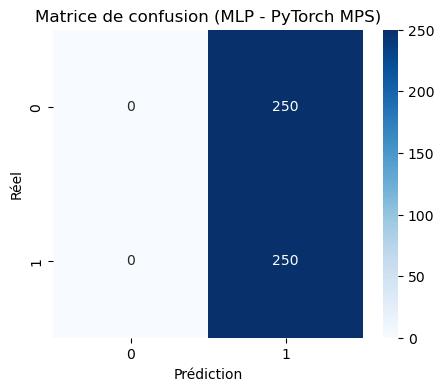

/Users/oumar/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/oumar/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/oumar/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [18]:

# --------------------------------------------------------------
# 7️⃣ ÉVALUATION FINALE
# --------------------------------------------------------------
model.load_state_dict(torch.load("models/best_model_mps.pt"))
model.eval()
with torch.no_grad():
    y_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        y_pred.extend(outputs.cpu().numpy())
y_pred_bin = (np.array(y_pred).flatten() > 0.5).astype(int)

print("\n===== RAPPORT DE CLASSIFICATION =====")
print(classification_report(y_test, y_pred_bin))

cm = confusion_matrix(y_test, y_pred_bin)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion (MLP - PyTorch MPS)")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()

# --------------------------------------------------------------
# 8️⃣ SAUVEGARDE DU RAPPORT
# --------------------------------------------------------------
with open("reports/rapport_classification_torch.txt", "w", encoding="utf-8") as f:
    f.write("===== RAPPORT DE CLASSIFICATION (PyTorch M2 Pro) =====\n\n")
    f.write(classification_report(y_test, y_pred_bin))
    f.write(f"\nF1-score final : {best_f1:.4f}\n")
